# mini-Prescience — model showcase

Short walkthrough of the trained delay-risk model: what it actually learned, how
confident it is, and what a real explained prediction looks like. See `docs/diagrams/
training-flow.excalidraw` for the full walk-forward CV methodology and
`notebooks/eda.ipynb` for the raw-data exploration this was built on.


In [1]:
import sys
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import pandas as pd

from backend.model_service import get_model, get_feature_importance, build_feature_row, _top_factors


/usr/local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## The model

LightGBM binary classifier, `delayed_15min` target (~5% positive rate), loaded from the MLflow run tagged `final_model`.

In [2]:
model = get_model()
print(f"{len(model.feature_name())} features")
print(f"{model.num_trees()} trees")
model.feature_name()


17 features
157 trees


['adep',
 'hour_of_day',
 'day_of_week',
 'month',
 'is_weekend',
 'is_holiday',
 'temperature_2m',
 'precipitation',
 'wind_speed_10m',
 'visibility_mi',
 'ceiling_ft',
 'flight_category',
 'traffic_1h',
 'traffic_3h',
 'delay_rate_1h',
 'delay_rate_3h',
 'typecode']

## Feature importance

Global ranking (gain-based) across the whole trained model — not the same as a single
prediction's explanation below, this is "on average, across ~2.3M training rows, what
did splitting on this feature reduce error the most." `typecode` dominates here because
it's a real, specific value at training time; live serving usually can't supply one
(see the per-airport vs per-aircraft distinction in the app itself).


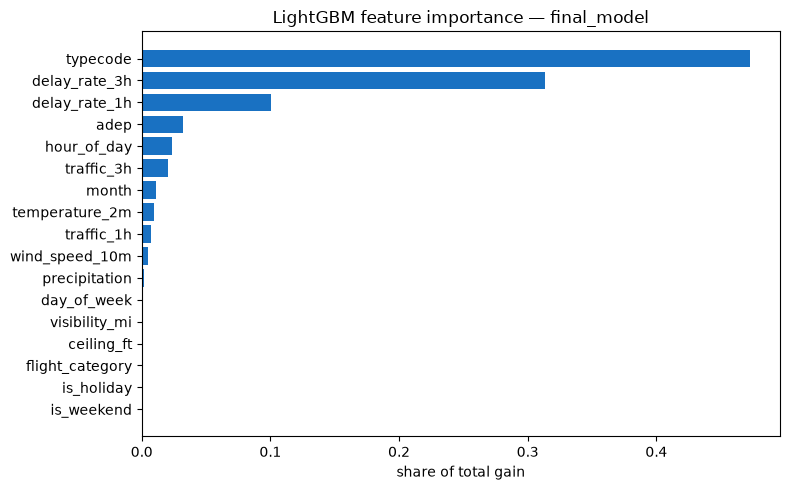

In [3]:
imp = pd.DataFrame(get_feature_importance())
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp["feature"][::-1], imp["importance"][::-1], color="#1971c2")
ax.set_xlabel("share of total gain")
ax.set_title("LightGBM feature importance — final_model")
fig.tight_layout()
plt.show()


## A single explained prediction

This mirrors exactly what the live app does when you click an airport: build one
feature row from current-ish conditions, score it, then pull the model's own
`pred_contrib` (real per-row SHAP-style attribution) for the top drivers — not a
global ranking, but what actually moved *this* prediction.


In [4]:
example_weather = {"temperature_2m": 8.0, "precipitation": 2.5, "wind_speed_10m": 32.0}
example_metar = {"visibility_mi": 2.5, "ceiling_ft": 800, "flight_category": 2}  # IFR

X = build_feature_row("EDDM", traffic_1h=18, traffic_3h=41, weather=example_weather, metar=example_metar)
score = float(model.predict(X)[0])
print(f"risk score: {score:.1%}")

for f in _top_factors(model, X, top_n=5):
    arrow = "▲" if f["direction"] == "increases" else "▼"
    print(f"  {arrow} {f['label']:<24} ({f['value']:>8})  contribution={f['contribution']:+.3f}")


risk score: 52.5%
  ▲ airport baseline         (    EDDM)  contribution=+0.380
  ▲ wind speed               (32.0 km/h)  contribution=+0.110
  ▼ time of day              (   16:00)  contribution=-0.087
  ▼ time of year             (     Aug)  contribution=-0.083
  ▲ precipitation            (  2.5 mm)  contribution=+0.055


## Held-out test performance

From the walk-forward CV training run (`ml/train.py`), on 272,546 rows from
2025-09-01 onward — touched exactly once, after hyperparameters were already chosen
from 4 rolling validation folds.

| metric | value |
|---|---|
| AUC | 0.7459 |
| PR-AUC | 0.2003 |
| F1 | 0.2528 |
| precision | 0.2769 |
| recall | 0.2325 |

PR-AUC is the more honest number here given the ~5% positive rate — AUC is easy to
inflate on an imbalanced target without the model being useful at the decision
threshold that actually matters operationally.
